In [75]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
BATCH_SIZE=32
IMAGE_SIZE=256
EPOCHS=50
CHANNELS=3


In [3]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "plant-village",
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2134 files belonging to 3 classes.


In [4]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
len(dataset)  #67*32 images

67

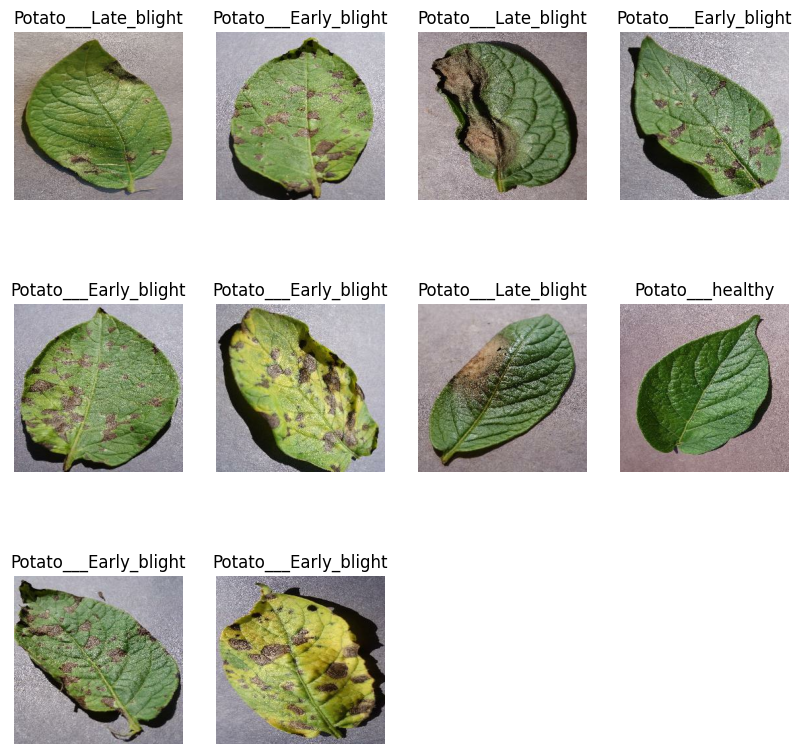

In [6]:
plt.figure(figsize=(10,10))
for batch_set,label_set in dataset.take(1):
    for i in range(10):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(batch_set[i].numpy().astype('uint8'))
        plt.title(class_names[label_set[i]])
        plt.axis("off")

In [7]:
len(dataset)

67

In [8]:
train_set=dataset.take(54)
remain_set=dataset.skip(54)

In [9]:
len(train_set)

54

In [10]:
def dataset_partition(ds,train_split,test_split,val_split,shuffle,shuffle_size):
    size=len(ds)
    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=12)
    train_size=int(train_split*size)
    test_size=int(test_split*size)
    val_size=int(val_split*size)
    train_set=ds.take(train_size)
    val_set=ds.skip(train_size).take(val_size)
    test_set=ds.skip(train_size).skip(val_size)

    return train_set,test_set,val_set
    

In [11]:
train_dataset,test_dataset,val_dataset=dataset_partition(dataset,0.8,0.1,0.1,True,10000)

In [12]:
train_ds=train_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [13]:
resize_rescale=tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])
    

In [14]:
data_agumentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [15]:
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes=3
model=tf.keras.Sequential([
    resize_rescale,
    data_agumentation,
    layers.Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='softmax'),
])
model.build(input_shape=input_shape)
    
    

C:\Users\Suraj_Anagandula\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [18]:
history=model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.5154 - loss: 0.9087 - val_accuracy: 0.7552 - val_loss: 0.8539
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.6726 - loss: 0.7476 - val_accuracy: 0.6250 - val_loss: 0.7837
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.8244 - loss: 0.4377 - val_accuracy: 0.7344 - val_loss: 0.7960
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.8731 - loss: 0.3404 - val_accuracy: 0.8177 - val_loss: 0.5042
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8814 - loss: 0.3176 - val_accuracy: 0.8646 - val_loss: 0.3003
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.8891 - loss: 0.2808 - val_accuracy: 0.8854 - val_loss: 0.2800
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9116 - loss: 0.2321 - val_accuracy: 0.8802 - val_loss: 0.2889
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9229 - loss: 0.1917 - val_accuracy: 0.8698 - va

In [19]:
scores=model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 319ms/step - accuracy: 0.9844 - loss: 0.0318


In [21]:
scores
#loss and accuracy

[0.03178008273243904, 0.984375]

In [23]:
acc=history.history['accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
val_acc=history.history['val_accuracy']


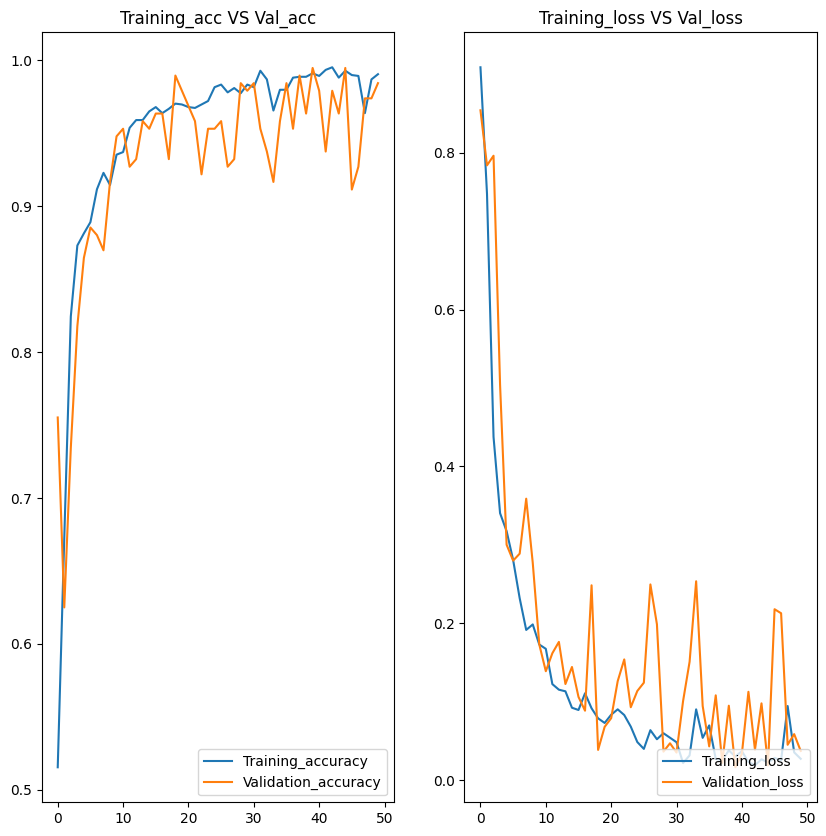

In [27]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label="Training_accuracy")
plt.plot(range(EPOCHS),val_acc,label="Validation_accuracy")
plt.legend(loc="lower right")
plt.title("Training_acc VS Val_acc")
plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label="Training_loss")
plt.plot(range(EPOCHS),val_loss,label="Validation_loss")
plt.legend(loc="lower right")
plt.title("Training_loss VS Val_loss")
plt.show()

original_class: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
predicted_class:Potato___Early_blight


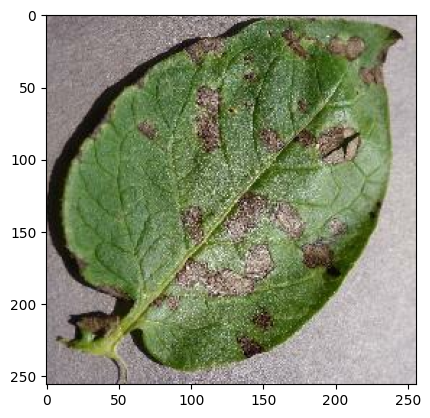

In [43]:
for batch_set,label_set in test_ds.take(1):
    plt.imshow(batch_set[0].numpy().astype('uint8'))
    print(f"original_class: {class_names[label_set[0].numpy()]}")
    pred_batch=model.predict(batch_set)
    print(f"predicted_class:{class_names[np.argmax(pred_batch[0])]}")
    

In [58]:
def predict(model,image):
    img_array=tf.keras.preprocessing.image.img_to_array(image)
    img_array=tf.expand_dims(img_array,0) # create batch
    pred=model.predict(img_array)
    predicted_class=class_names[np.argmax(pred[0])]
    confidence=round(100*(np.max(pred[0])),2)
    return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


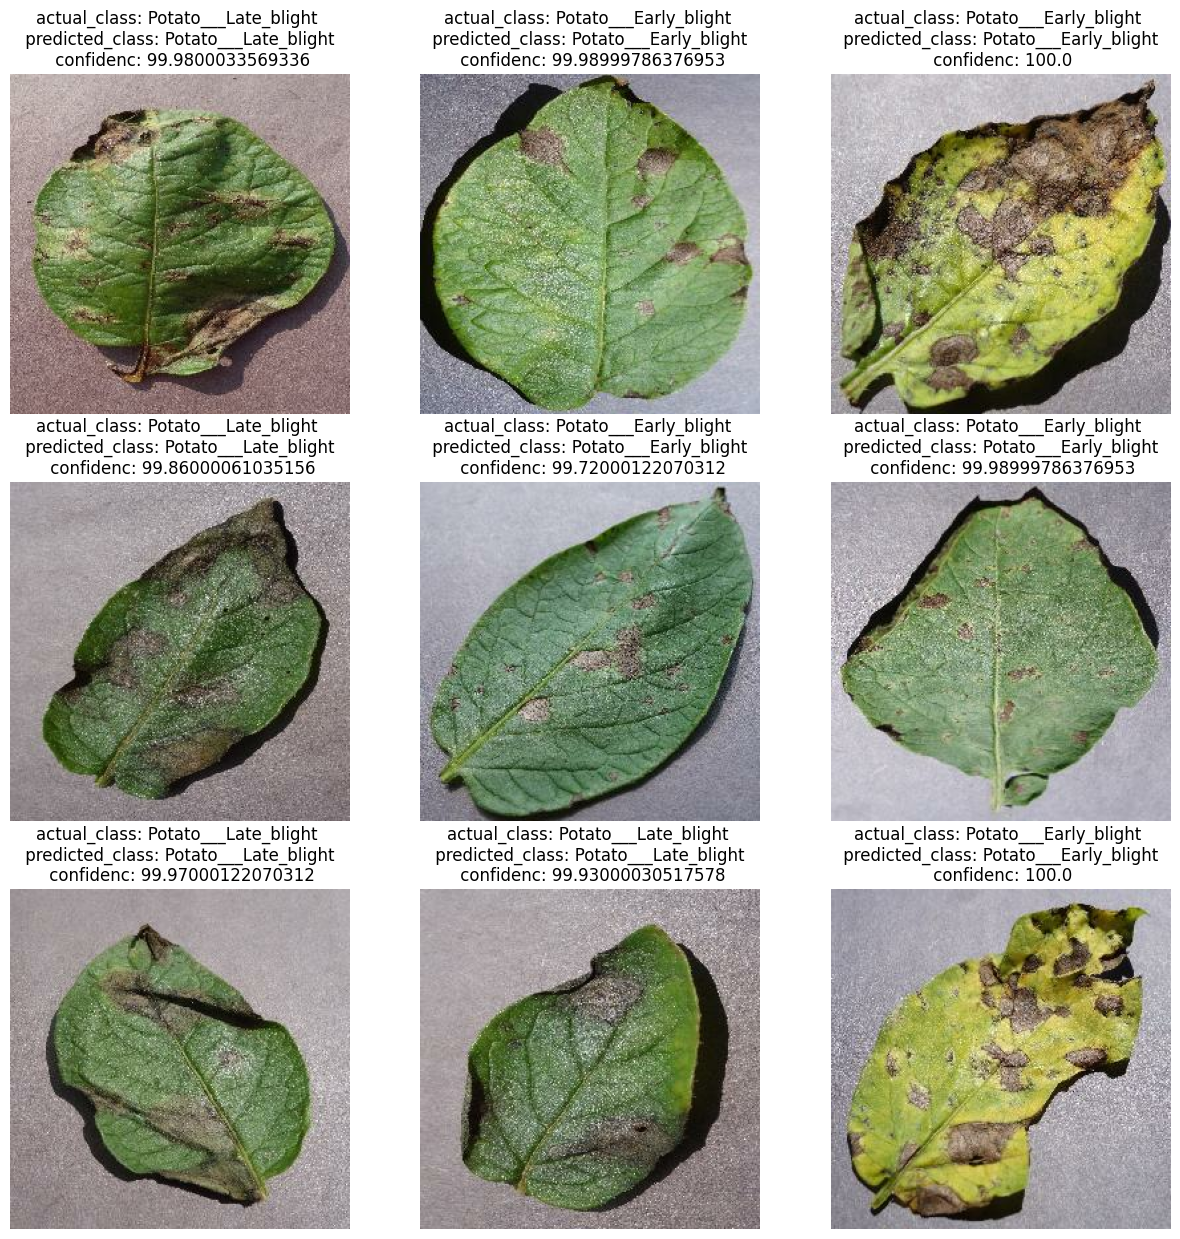

In [72]:
plt.figure(figsize=(15,15))
for image,label in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype("uint8"))
        pred,conf=predict(model,image[i].numpy())
        plt.title(f"actual_class: {class_names[label[i]]} \n predicted_class: {pred} \n confidenc: {conf}") 
        plt.axis("off")
         
        

In [73]:
model_version=1
model.save(f"../models/{model_version}")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=../models/1.

In [76]:
print(os.getcwd())

C:\Users\Suraj_Anagandula\Desktop\potato_disease
